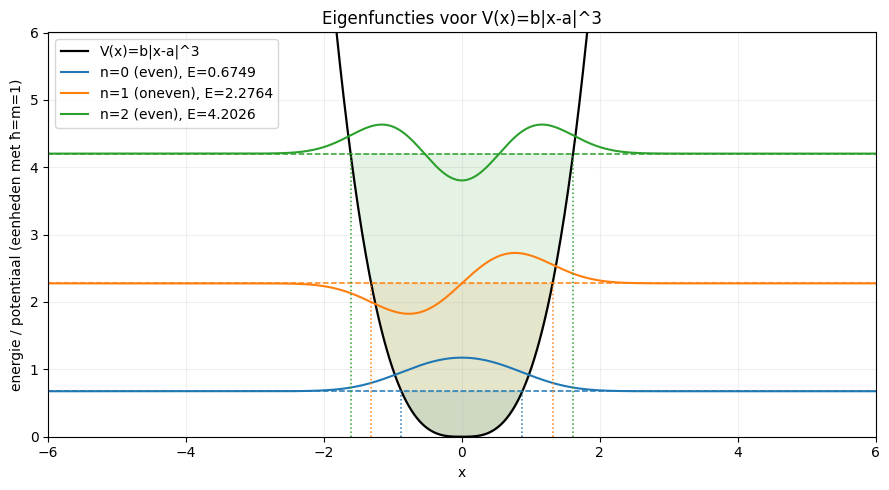

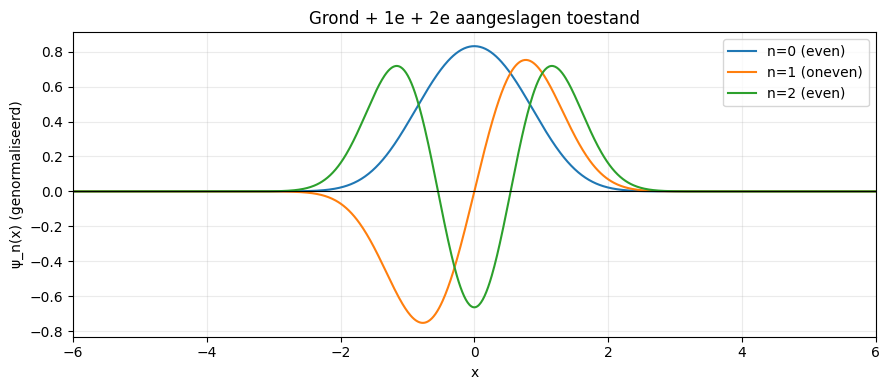

Energies (n=0,1,2): [0.67488    2.27643323 4.20255294]


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Probeer sparse eigensolver (snel). Als SciPy niet beschikbaar is, valt hij terug op dense.
try:
    import scipy.sparse as sp
    import scipy.sparse.linalg as spla
    HAVE_SCIPY = True
except Exception:
    HAVE_SCIPY = False

def solve_cubic_abs_well(b=1.0, a=0.0, m=1.0, hbar=1.0, L=8.0, N=1200, k=4):
    """
    Los de 1D TISE numeriek op voor V(x)=b|x-a|^3 op [-L,L] met Dirichlet randen psi(-L)=psi(L)=0.
    Geeft x, V, energies E (k laagste), en eigenfuncties psi[:,n] (genormaliseerd).
    """
    x = np.linspace(-L, L, N)
    dx = x[1] - x[0]

    V = b * np.abs(x - a)**3

    main = -2.0 * np.ones(N)
    off  =  1.0 * np.ones(N-1)

    if HAVE_SCIPY:
        D2 = sp.diags([off, main, off], [-1, 0, 1], format="csr") / dx**2
        H  = -(hbar**2/(2*m)) * D2 + sp.diags(V, 0, format="csr")
        evals, evecs = spla.eigsh(H, k=k, which="SA")  # smallest algebraic
        idx = np.argsort(evals)
        evals, evecs = evals[idx], evecs[:, idx]
    else:
        # Dense fallback: zet N dan liever ~400-600
        D2 = (np.diag(off, -1) + np.diag(main, 0) + np.diag(off, 1)) / dx**2
        H  = -(hbar**2/(2*m)) * D2 + np.diag(V)
        evals, evecs = np.linalg.eigh(H)
        evals, evecs = evals[:k], evecs[:, :k]

    # Normaliseer: ∫|psi|^2 dx = 1
    psis = np.zeros_like(evecs)
    for n in range(evecs.shape[1]):
        psi = evecs[:, n]
        # vaste sign-conventie (maakt plots consistenter)
        if psi[-2] < 0:
            psi = -psi
        norm = np.sqrt(np.sum(np.abs(psi)**2) * dx)
        psis[:, n] = psi / norm

    return x, V, evals, psis

def parity_about_a(x, psi, a=0.0):
    """
    Pariteit rond x=a: vergelijk psi(a+u) met psi(a-u).
    We nemen aan dat het grid symmetrisch en a ~ 0 of netjes op grid ligt.
    """
    psi_flip = psi[::-1]
    c = np.dot(psi, psi_flip) / np.dot(psi, psi)  # ~ +1 even, ~ -1 oneven
    return "even" if c > 0 else "oneven"

# ======= Kies parameters =======
b = 1.0     # sterkte
a = 0.0     # minimum op x=a
m = 1.0
hbar = 1.0
L = 8.0     # domein halfbreedte (moet groot genoeg zijn)
N = 1200    # gridpunten
k = 4       # hoeveel toestanden je wil

x, V, E, psi = solve_cubic_abs_well(b=b, a=a, m=m, hbar=hbar, L=L, N=N, k=k)
par = [parity_about_a(x, psi[:,n], a=a) for n in range(k)]

# ======= Plot 1: V + energies + (geschaalde) psi's =======
plt.close("abs_cubic_overview")
fig, ax = plt.subplots(num="abs_cubic_overview", figsize=(9, 5))
ax.plot(x, V, color="black", linewidth=1.6, label="V(x)=b|x-a|^3")

scale = 0.6  # visuele schaal voor psi's
colors = ["C0", "C1", "C2", "C3"]

for n in range(3):  # grond + 1e + 2e aangeslagen
    xt = (E[n]/b)**(1/3)
    in_classical = (x >= a - xt) & (x <= a + xt)
    ax.fill_between(x[in_classical], V[in_classical], E[n], color=colors[n], alpha=0.12)
    ax.hlines(E[n], x.min(), x.max(), linestyles="dashed", linewidth=1.1, color=colors[n])
    ax.vlines([a-xt, a+xt], 0, E[n], linestyles="dotted", linewidth=1.1, colors=colors[n])
    ax.plot(x, E[n] + scale*psi[:,n], color=colors[n], label=f"n={n} ({par[n]}), E={E[n]:.4f}")

ax.set_xlim(a-6, a+6)
ax.set_ylim(0, min(V.max(), E[2] + 3*scale))
ax.set_xlabel("x")
ax.set_ylabel("energie / potentiaal (eenheden met ħ=m=1)")
ax.set_title("Eigenfuncties voor V(x)=b|x-a|^3")
ax.legend(loc="upper left")
ax.grid(alpha=0.2)
fig.tight_layout()
plt.show()

# ======= Plot 2: psi's apart (genormaliseerd) =======
plt.close("abs_cubic_wavefunctions")
fig2, ax2 = plt.subplots(num="abs_cubic_wavefunctions", figsize=(9, 4))
for n in range(3):
    ax2.plot(x, psi[:,n], color=colors[n], label=f"n={n} ({par[n]})")
ax2.axhline(0, color="black", linewidth=0.8)
ax2.set_xlim(a-6, a+6)
ax2.set_xlabel("x")
ax2.set_ylabel("ψ_n(x) (genormaliseerd)")
ax2.set_title("Grond + 1e + 2e aangeslagen toestand")
ax2.legend()
ax2.grid(alpha=0.25)
fig2.tight_layout()
plt.show()

print("Energies (n=0,1,2):", E[:3])

### Uitleg bij de figuren
- Plot 1 toont het potentiaal $V(x)=b|x-a|^3$ (zwart), de drie laagste energie ebn (stippellijnen) en de genormaliseerde golffuncties verschoven omhoog per energie. De lichtgekleurde vlakken markeren de klassiek toegestane regio $|x-a| \le (E/b)^{1/3}$.
- De pariteit wordt uit de numerieke oplossing gehaald: `even` betekent symmetrisch rond $x=a$, `oneven` antisymmetrisch. Dat verklaart waarom opeenvolgende toestanden alterneren in symmetrie.
- Plot 2 toont dezelfde drie golffuncties zonder verticale verschuiving, zodat nuldoorgangen en symmetrie duidelijk zichtbaar zijn.
- Parameters staan bovenaan gegroepeerd (b, a, m, hbar, L, N, k). Pas ze aan en draai de cel opnieuw om meteen een aangepaste figuur te krijgen.